In [1]:
#import libraries for exploratory analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")

In [5]:
df.head(2)

,employee_id,first_name,last_name,email,gender,age,location,department,role,experience_years,tenure_years,salary_band,bonus,performance_score,training_hours,overtime_hours,projects_assigned,satisfaction_score,work_life_balance,attrition
0,1001,Tiffany,Hamilton,tiffanyhamilton692@gmail.com,Male,29,Mumbai,Operations,Senior Associate,2,0.55,Low,3286,1.66,46.0,12.92,10,65.66,3.02,0
1,1002,Brenda,Lewis,brendalewis540@gmail.com,Female,34,Hyderabad,Engineering,Associate,12,4.19,Low,1695,4.36,55.0,14.55,6,75.40,3.33,0


In [6]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         35000 non-null  int64  
 1   first_name          35000 non-null  object 
 2   last_name           35000 non-null  object 
 3   email               35000 non-null  object 
 4   gender              35000 non-null  object 
 5   age                 35000 non-null  int64  
 6   location            35000 non-null  object 
 7   department          35000 non-null  object 
 8   role                35000 non-null  object 
 9   experience_years    35000 non-null  int64  
 10  tenure_years        35000 non-null  float64
 11  salary_band         35000 non-null  object 
 12  bonus               35000 non-null  int64  
 13  performance_score   35000 non-null  float64
 14  training_hours      35000 non-null  float64
 15  overtime_hours      35000 non-null  float64
 16  proj

(35000, 20)

Overall attrition rate: 20.42%


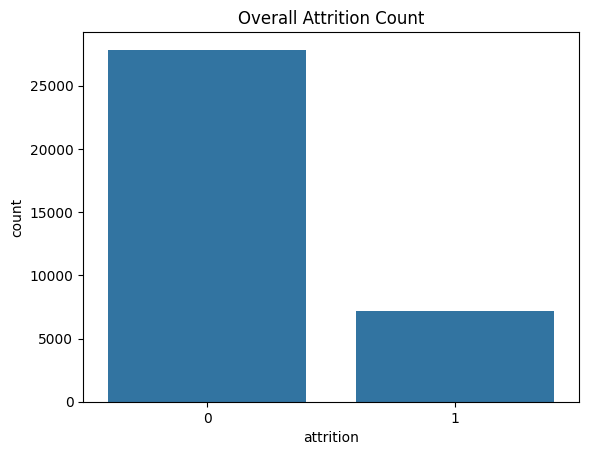

In [8]:
#Attrition Rate
attrition_rate = df["attrition"].mean()*100
print(f"Overall attrition rate: {attrition_rate:.2f}%")

sns.countplot(x="attrition", data=df)
plt.title("Overall Attrition Count")
plt.show()

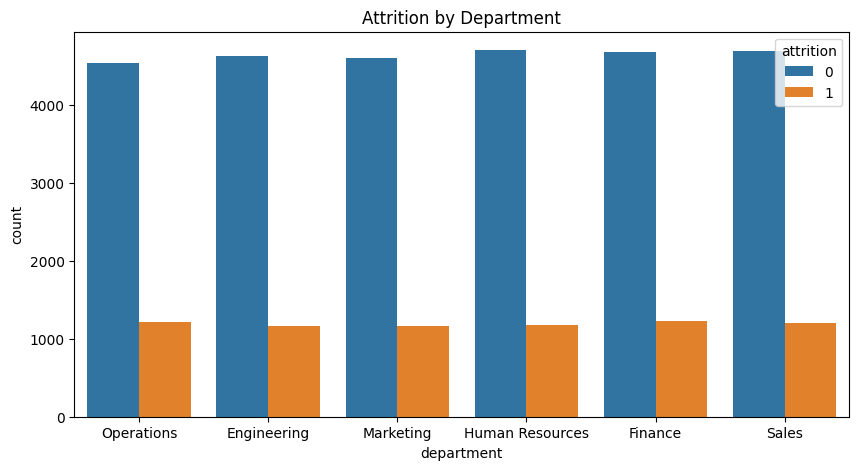

department
Operations         0.211405
Finance            0.207557
Sales              0.203189
Marketing          0.201838
Engineering        0.201276
Human Resources    0.200170
Name: attrition, dtype: float64


In [12]:
#Attrition by Department
plt.figure(figsize=(10,5))
sns.countplot(x="department", hue="attrition", data=df)
plt.title("Attrition by Department")
plt.show()

dept_attrition = df.groupby("department")["attrition"].mean().sort_values(ascending=False)
print(dept_attrition)

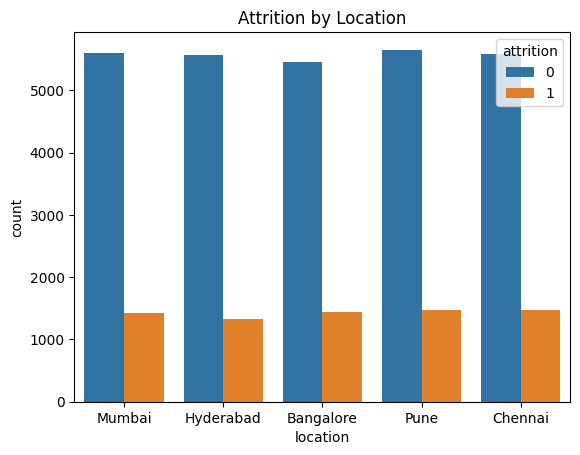

In [14]:
#Attrition by Location
sns.countplot(x="location", hue="attrition", data=df)
plt.title("Attrition by Location")
plt.show()

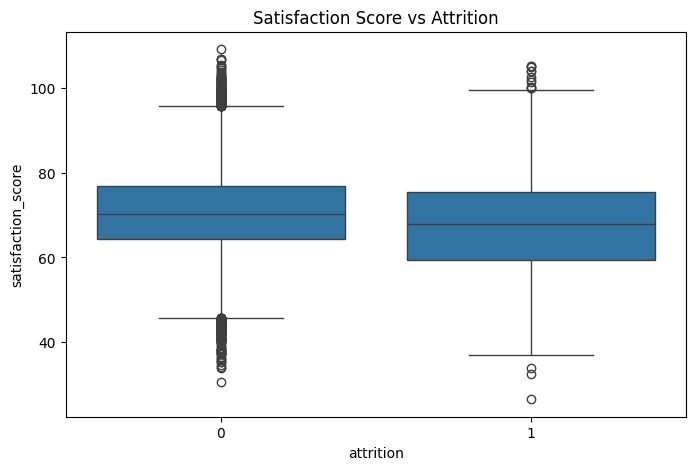

In [16]:
#Satisfaction vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x="attrition", y="satisfaction_score", data=df)
plt.title("Satisfaction Score vs Attrition")
plt.show()

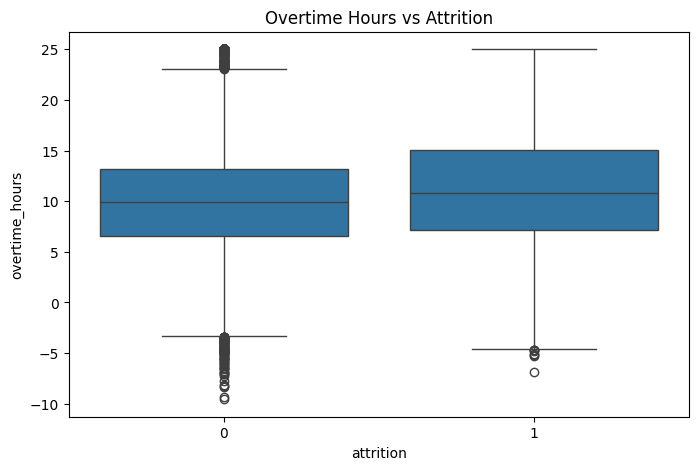

In [17]:
#Overtime vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x="attrition", y="overtime_hours", data=df)
plt.title("Overtime Hours vs Attrition")
plt.show()

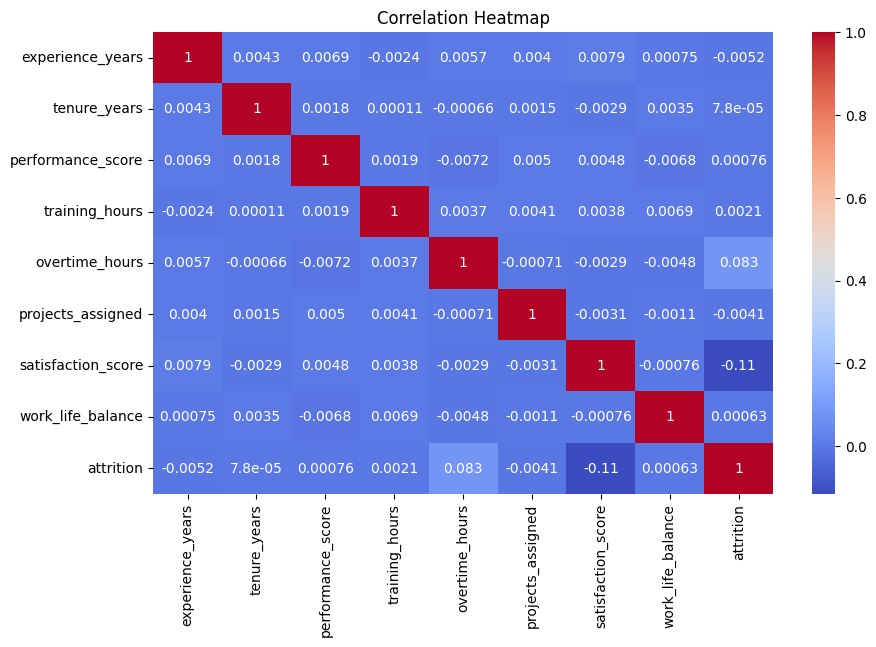

In [18]:
#Correlation Heatmap
numeric_cols = ["experience_years","tenure_years","performance_score",
                "training_hours","overtime_hours","projects_assigned",
                "satisfaction_score","work_life_balance","attrition"]

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
# Average satisfaction per department
df.groupby("department")["satisfaction_score"].mean()

# Average tenure per department
df.groupby("department")["tenure_years"].mean()

# Attrition % per location
df.groupby("location")["attrition"].mean()*100

location
Bangalore    20.982466
Chennai      20.864635
Hyderabad    19.172113
Mumbai       20.318725
Pune         20.754452
Name: attrition, dtype: float64

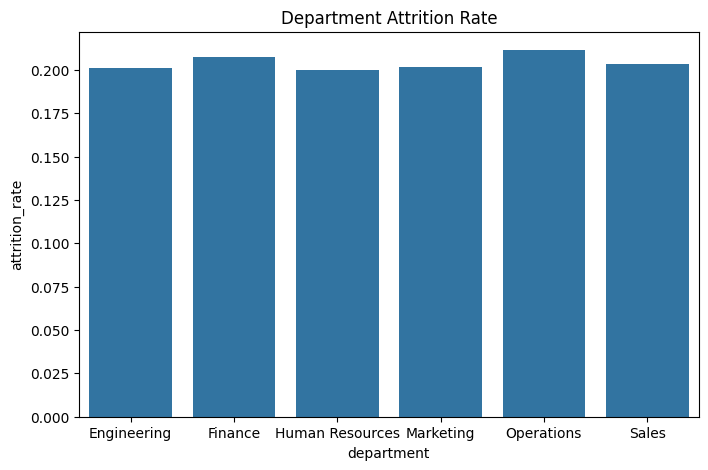

In [22]:
#Department Attrition Rate
plt.figure(figsize=(8,5))
sns.barplot(x="department", y="attrition_rate", data=kpi_df)
plt.title("Department Attrition Rate")
plt.savefig("../images/department_attrition.png")